In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
transform = transforms.ToTensor()

In [4]:
train_data = datasets.CIFAR10(root='./Data',train=True,download=True,transform=transform)

Files already downloaded and verified


In [5]:
test_data = datasets.CIFAR10(root='./Data',train=False,download=True,transform=transform)

Files already downloaded and verified


In [6]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [7]:
test_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [8]:
train_loader = DataLoader(train_data,batch_size=10,shuffle=True)

In [9]:
test_loader = DataLoader(test_data,batch_size=10,shuffle=False)

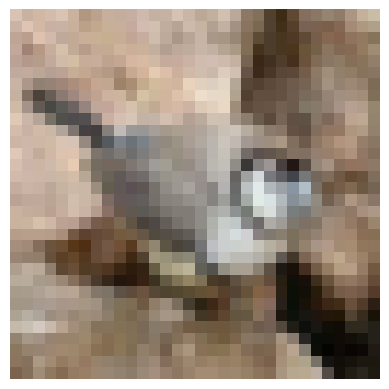

In [11]:
image, label = train_data[90]

plt.imshow(image.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [21]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,1)
        self.conv2 = nn.Conv2d(32,64,3,1)
        self.conv3 = nn.Conv2d(64,128,3,1)
        self.fc1 = nn.Linear(2*2*128,250)
        self.fc2 = nn.Linear(250,100)
        self.fc3 = nn.Linear(100,10)

    def forward(self,X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.conv3(X))
        X = F.max_pool2d(X,2,2)
        X = X.view(-1,2*2*128)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X,dim=1)

In [22]:
torch.manual_seed(13)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=512, out_features=250, bias=True)
  (fc2): Linear(in_features=250, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [33]:
import time
start_time = time.time()

epochs = 10
train_losses= []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr=0
    tst_corr=0

    for b,(X_train,y_train) in enumerate(train_loader):
        b+=1
        
        y_pred = model(X_train)
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data,1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr+=batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%500 == 0:
            print(f" Epoch: {i:2} Batch {b:4} [{10*b:6}/50000] loss: {loss.item():10.8f} accuracy: {trn_corr.item()*100/(10*b):7.3f}%')")
  

    train_losses.append(loss.item())
    train_correct.append(trn_corr.item())

    with torch.no_grad():
        for b,(X_test,y_test) in enumerate(test_loader):
            y_val= model(X_test)

            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted == y_test).sum()

        loss = criterion(y_val,y_test)
        test_correct.append(tst_corr.item())
        test_losses.append(loss.item())





print(f"\nDuration: {time.time() - start_time:.0f} seconds")

 Epoch:  0 Batch  500 [  5000/50000] loss: 0.54736859 accuracy:  76.820%')
 Epoch:  0 Batch 1000 [ 10000/50000] loss: 0.99748880 accuracy:  77.060%')
 Epoch:  0 Batch 1500 [ 15000/50000] loss: 0.49727350 accuracy:  76.967%')
 Epoch:  0 Batch 2000 [ 20000/50000] loss: 0.94019520 accuracy:  76.670%')
 Epoch:  0 Batch 2500 [ 25000/50000] loss: 0.45473027 accuracy:  76.480%')
 Epoch:  0 Batch 3000 [ 30000/50000] loss: 0.81290787 accuracy:  76.323%')
 Epoch:  0 Batch 3500 [ 35000/50000] loss: 0.61045051 accuracy:  76.337%')
 Epoch:  0 Batch 4000 [ 40000/50000] loss: 1.04929519 accuracy:  76.172%')
 Epoch:  0 Batch 4500 [ 45000/50000] loss: 0.48400360 accuracy:  76.138%')
 Epoch:  0 Batch 5000 [ 50000/50000] loss: 0.60275733 accuracy:  76.184%')
 Epoch:  1 Batch  500 [  5000/50000] loss: 0.50426584 accuracy:  78.800%')
 Epoch:  1 Batch 1000 [ 10000/50000] loss: 0.39391825 accuracy:  78.930%')
 Epoch:  1 Batch 1500 [ 15000/50000] loss: 0.06610649 accuracy:  78.893%')
 Epoch:  1 Batch 2000 [ 2

Text(0.5, 1.0, 'loss')

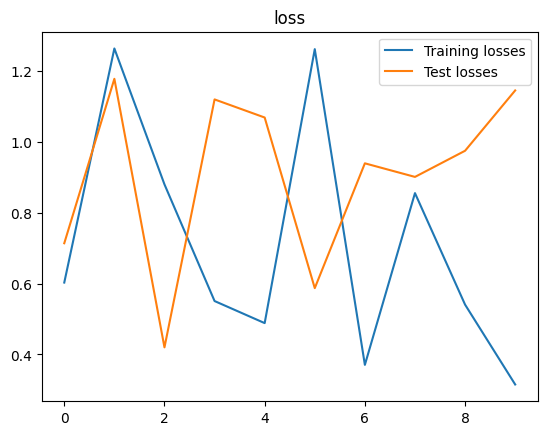

In [34]:
plt.plot(train_losses,label="Training losses")
plt.plot(test_losses,label="Test losses")
plt.legend()
plt.title("loss")


Text(0.5, 1.0, 'Accuracy')

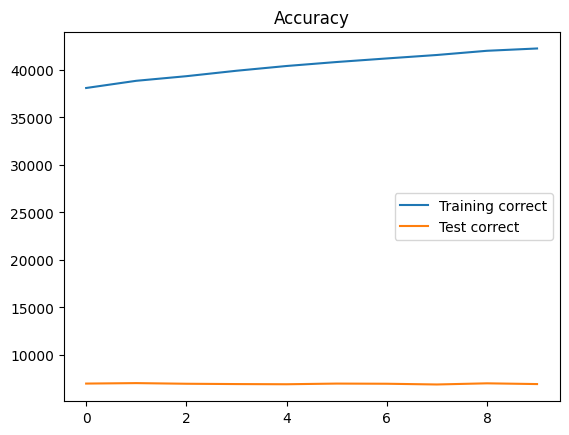

In [35]:
plt.plot(train_correct,label="Training correct")
plt.plot(test_correct,label="Test correct")
plt.legend()
plt.title("Accuracy")


In [36]:
print(F"Training Accuracy: {train_correct[-1]/500:.2f}%")
print(F"Test Accuracy: {test_correct[-1]/100:.2f}%")

Training Accuracy: 84.50%
Test Accuracy: 69.40%
